In [2]:
# ============================================================
# CELDA 1. LIBRERÍAS Y CONFIGURACIÓN VISUAL
# ============================================================
# En esta celda cargamos las librerías necesarias.
#
# - pandas y numpy: para trabajar con tablas y cálculos
# - matplotlib y seaborn: para las gráficas
#
# El objetivo es que el análisis no solo calcule métricas,
# sino que también las explique visualmente.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

In [3]:
# ============================================================
# CELDA 2. CARGA DE DATOS
# ============================================================
# Aquí debes indicar las rutas a:
# - JSON del partido
# - CSV de tipos de evento
# - CSV de qualifiers Opta
#
# Esto permite traducir códigos numéricos (typeId, qualifierId)
# a nombres comprensibles.

# ============================================================
# 1. IMPORTS
# ============================================================

import boto3
import pandas as pd
import numpy as np
import json
import io
from pprint import pprint

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)

# ============================================================
# 2. CONFIG S3
# ============================================================

BUCKET = "rayo-scout-data"

KEY = (
    "ligas_seleccionadas/"
    "testeo_ligas_europa/"
    "Spain_Primera_Division/"
    "2025-2026/"
    "partidos/"
    "1_Girona_Rayo_1f9e25njwyjk6ruheatqgglw.json"
)

REGION = "eu-west-1"

# ============================================================
# 3. CONEXIÓN S3
# ============================================================

s3 = boto3.client(
    "s3",
    region_name=REGION
)

# ============================================================
# 4. CARGAR JSON
# ============================================================

obj = s3.get_object(
    Bucket=BUCKET,
    Key=KEY
)

data = json.loads(
    obj["Body"].read().decode("utf-8")
)

EVENT_TYPES_CSV = "F1_opta_event_types.csv"
QUALIFIER_TYPES_CSV = "F3_opta_qualifier_types.csv"
event_types_df = pd.read_csv(EVENT_TYPES_CSV)
qualifier_types_df = pd.read_csv(QUALIFIER_TYPES_CSV)

print("Datos cargados correctamente.")

Datos cargados correctamente.


In [4]:
# ============================================================
# CELDA 3. LIMPIEZA DE TABLAS AUXILIARES
# ============================================================
# Los CSV pueden tener filas vacías o duplicadas.
# Limpiamos esas tablas para poder hacer mapeos fiables.

event_types_clean = (
    event_types_df
    .dropna(subset=["eventTypeId"])
    .drop_duplicates(subset=["eventTypeId"])
    .copy()
)
event_types_clean["eventTypeId"] = event_types_clean["eventTypeId"].astype(int)

qualifier_types_clean = (
    qualifier_types_df
    .dropna(subset=["qualifierTypeId"])
    .drop_duplicates(subset=["qualifierTypeId"])
    .copy()
)
qualifier_types_clean["qualifierTypeId"] = qualifier_types_clean["qualifierTypeId"].astype(int)

type_map = dict(zip(event_types_clean["eventTypeId"], event_types_clean["eventTypeName"]))
qual_map = dict(zip(qualifier_types_clean["qualifierTypeId"], qualifier_types_clean["qualifierTypeName"]))

print("Tablas auxiliares preparadas.")

Tablas auxiliares preparadas.


In [5]:
# ============================================================
# CELDA 4. IDENTIFICAR EQUIPOS
# ============================================================
# Necesitamos saber qué contestantId corresponde a cada equipo.
# Así podremos comparar Rayo Vallecano con su rival.

contestants = data["matchInfo"]["contestant"]

team_home = None
team_away = None

for c in contestants:
    position = str(c.get("position", "")).lower()
    if position == "home":
        team_home = c
    elif position == "away":
        team_away = c

if team_home is None or team_away is None:
    if len(contestants) >= 2:
        team_home = contestants[0]
        team_away = contestants[1]

HOME_ID = team_home["id"]
AWAY_ID = team_away["id"]

HOME_NAME = team_home["name"]
AWAY_NAME = team_away["name"]

print("Equipo local:", HOME_NAME)
print("Equipo visitante:", AWAY_NAME)

Equipo local: Girona
Equipo visitante: Rayo Vallecano


In [6]:
# ============================================================
# CELDA 5. CONSTRUIR EL DATAFRAME DE EVENTOS
# ============================================================
# Convertimos la lista de eventos del JSON en una tabla.
#
# Cada fila será un evento del partido:
# pase, recuperación, tiro, falta, etc.
#
# También aplanamos los qualifiers para poder usarlos después.

raw_events = data["liveData"]["event"]

rows = []
for e in raw_events:
    row = {
        "id": e.get("id"),
        "eventId": e.get("eventId"),
        "typeId": e.get("typeId"),
        "periodId": e.get("periodId"),
        "timeMin": e.get("timeMin"),
        "timeSec": e.get("timeSec"),
        "contestantId": e.get("contestantId"),
        "playerId": e.get("playerId"),
        "outcome": e.get("outcome"),
        "x": e.get("x"),
        "y": e.get("y"),
    }

    for q in e.get("qualifier", []):
        qid = q.get("qualifierId")
        if qid is not None:
            row[f"q_{qid}"] = q.get("value")

    rows.append(row)

df = pd.DataFrame(rows)

df["typeName"] = df["typeId"].map(type_map)
df["team"] = df["contestantId"].map({
    HOME_ID: HOME_NAME,
    AWAY_ID: AWAY_NAME
})

df["timestamp"] = df["timeMin"].fillna(0) * 60 + df["timeSec"].fillna(0)

# Solo tiempo reglamentario
df_match = df[df["periodId"].isin([1, 2])].copy()
df_match = df_match.sort_values(by=["periodId", "timeMin", "timeSec", "id"]).reset_index(drop=True)

print("Eventos del partido en tiempo reglamentario:", len(df_match))
df_match.head()

Eventos del partido en tiempo reglamentario: 1710


,id,eventId,typeId,periodId,timeMin,timeSec,contestantId,playerId,outcome,x,y,q_197,q_130,q_44,q_30,q_227,q_131,q_194,q_59,q_127,q_279,q_141,q_140,q_212,q_213,q_56,q_233,q_236,q_1,q_286,q_157,q_285,q_347,q_107,q_399,q_144,q_155,q_3,q_53,q_41,q_55,q_189,q_196,q_13,q_265,q_152,q_5,q_465,q_383,q_178,q_464,q_385,q_346,q_237,q_124,q_380,q_40,q_201,q_354,q_167,q_15,q_156,q_168,q_224,q_72,q_2,q_73,q_210,q_154,q_6,q_102,q_328,q_74,q_17,q_25,q_29,q_231,q_103,q_230,q_389,q_215,q_22,q_18,q_20,q_393,q_31,q_7,q_241,q_169,q_195,q_468,q_75,q_170,q_375,q_374,q_396,q_136,q_395,q_458,q_60,q_78,q_214,q_16,q_83,q_295,q_146,q_147,q_82,q_94,q_384,q_246,q_223,q_377,q_123,q_287,q_348,q_9,q_33,q_165,q_42,q_145,q_293,q_472,q_282,q_390,q_80,q_281,q_353,q_280,q_179,q_186,q_277,q_4,q_89,q_376,q_183,q_173,q_181,q_139,q_174,q_153,q_378,q_198,q_294,q_57,q_292,q_345,q_211,q_467,q_85,q_23,q_77,q_319,q_386,q_225,q_64,q_185,q_87,q_180,q_182,q_177,q_10,q_24,q_108,q_361,q_63,q_8,q_391,q_101,q_100,q_14,q_209,q_229,q_302,typeName,team,timestamp
0,2835057147,2,32,1,0,0,7h7eg7q7dbwvzww78h9d5eh0h,NaN,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right to Left,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Start,Girona,0
1,2835057151,2,32,1,0,0,3budh3j9xivsid3ptm8ptpy4k,NaN,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Left to Right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Start,Rayo Vallecano,0
2,2835057157,3,1,1,0,0,3budh3j9xivsid3ptm8ptpy4k,c157xhi78x9cykn7xz816bjd,1,49.8,49.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,59.3,35.2,16.6,2.75,Back,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pass,Rayo Vallecano,0
3,2835057185,4,1,1,0,3,3budh3j9xivsid3ptm8ptpy4k,u04ao1ldrjjesgqq52o7ghqt,1,35.2,59.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.3,34.9,15.6,4.69,Back,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [7]:
# ============================================================
# CELDA 6. FUNCIÓN AUXILIAR PARA QUALIFIERS
# ============================================================
# Muchos eventos dependen de qualifiers:
# - centro
# - córner
# - balón parado
# - big chance
#
# Esta función nos ayuda a detectar si un evento tiene un qualifier.

def has_qualifier(dataframe, q_id):
    col = f"q_{q_id}"
    if col in dataframe.columns:
        return dataframe[col].notna() & (dataframe[col] != "0") & (dataframe[col] != 0)
    return pd.Series(False, index=dataframe.index)

In [8]:
# ============================================================
# CELDA 7. FILTROS GLOBALES
# ============================================================
# Creamos filtros reutilizables para clasificar eventos.
#
# Esto hace el análisis más limpio y más fácil de entender.

es_pase = df_match["typeId"] == 1
es_tiro = df_match["typeId"].isin([13, 14, 15, 16])
es_gol = df_match["typeId"] == 16

# Balón parado:
# - qualifier 5: free kick taken
# - qualifier 6: corner taken
# - qualifier 107: throw in
es_balon_parado = has_qualifier(df_match, 5) | has_qualifier(df_match, 6) | has_qualifier(df_match, 107)

# Pase abierto completado
pases_abiertos_exito = es_pase & ~es_balon_parado & (df_match["outcome"] == 1)

# Acciones defensivas para PPDA y presión
acciones_defensivas_ppda = df_match["typeId"].isin([4, 7, 8, 12, 74])

# Acciones defensivas más amplias para contexto táctico
acciones_defensivas_amplias = df_match["typeId"].isin([4, 7, 8, 12, 44, 45, 49, 74])

print("Filtros preparados.")

Filtros preparados.


In [9]:
# ============================================================
# CELDA 8. RESUMEN INICIAL DEL PARTIDO
# ============================================================
# Antes de entrar en fases, mostramos qué eventos hubo.
# Esto ayuda a entender con qué tipo de partido estamos trabajando.

event_summary = (
    df_match.groupby(["typeId", "typeName"])
    .size()
    .reset_index(name="n_events")
    .sort_values("n_events", ascending=False)
)

print("=== TIPOS DE EVENTO DISPONIBLES EN EL PARTIDO ===")
display(event_summary)

=== TIPOS DE EVENTO DISPONIBLES EN EL PARTIDO ===


,typeId,typeName,n_events
0,1,Pass,943
4,5,Out,122
24,49,Ball recovery,77
32,61,Ball touch,69
22,44,Aerial,62
21,43,Deleted event,51
3,4,Foul,50
6,7,Tackle,40
9,12,Clearance,38
2,3,Take On,35


In [10]:
# ============================================================
# CELDA 9. FAMILIAS TÁCTICAS
# ============================================================
# Agrupamos los eventos en categorías más intuitivas.
# Esto es útil para explicar el partido sin depender del lenguaje técnico de Opta.

def classify_event_family(row):
    t = row["typeName"]

    if t in ["Pass", "Offside Pass"]:
        return "Pase"
    elif t in ["Goal", "Miss", "Saved Shot", "Post", "Chance missed"]:
        return "Finalización"
    elif t in ["Take On", "Dispossessed"]:
        return "1v1 / Regate"
    elif t in ["Tackle", "Interception", "Ball recovery", "Blocked Pass", "Clearance"]:
        return "Acción defensiva"
    elif t in ["Aerial", "Challenge", "50/50"]:
        return "Duelo"
    elif t in ["Foul", "Card"]:
        return "Disciplina / Faltas"
    elif t in ["Save", "Claim", "Punch", "Keeper Sweeper", "Keeper pick-up", "Smother", "Penalty faced"]:
        return "Portero"
    elif t in ["Turnover", "Error", "Ball touch"]:
        return "Pérdida / Error"
    else:
        return "Otros"

df_match["event_family"] = df_match.apply(classify_event_family, axis=1)

family_summary = (
    df_match["event_family"]
    .value_counts()
    .reset_index()
)
family_summary.columns = ["event_family", "n_events"]

display(family_summary)

,event_family,n_events
0,Pase,945
1,Otros,278
2,Acción defensiva,180
3,Duelo,78
4,Pérdida / Error,73
5,1v1 / Regate,59
6,Disciplina / Faltas,52
7,Finalización,23
8,Portero,22


In [11]:
# ============================================================
# CELDA 10. DEFINICIÓN OPERATIVA DE LAS 4 FASES
# ============================================================
# IMPORTANTE:
# El proveedor de datos no etiqueta directamente cada evento con una fase.
# Por tanto, construimos una lógica de análisis.
#
# Fases:
# 1. Ataque posicional:
#    juego con posesión más estable y más organizado.
#
# 2. Transición ofensiva:
#    momentos inmediatamente posteriores a una recuperación
#    donde el equipo intenta atacar rápido.
#
# 3. Defensa organizada:
#    acciones sin balón en estructura defensiva.
#
# 4. Transición defensiva:
#    lo que ocurre justo después de perder el balón.

df_match["prev_team"] = df_match["team"].shift(1)
df_match["possession_change"] = (df_match["team"] != df_match["prev_team"]).fillna(True)
df_match["possession_id"] = df_match["possession_change"].cumsum()

possession_summary = (
    df_match.groupby("possession_id")
    .agg(
        team=("team", "first"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        start_x=("x", "first"),
        end_x=("x", "last"),
        n_events=("id", "count")
    )
    .reset_index()
)

possession_summary["duration_sec"] = possession_summary["end_time"] - possession_summary["start_time"]
possession_summary["progress_x"] = possession_summary["end_x"] - possession_summary["start_x"]

# Transición ofensiva: posesión corta y vertical o fast break
fast_break_possessions = set(df_match.loc[has_qualifier(df_match, 23), "possession_id"].dropna().unique())

possession_summary["is_offensive_transition"] = (
    ((possession_summary["duration_sec"] <= 10) & (possession_summary["progress_x"] >= 15))
    | (possession_summary["possession_id"].isin(fast_break_possessions))
)

offensive_transition_possessions = set(
    possession_summary.loc[possession_summary["is_offensive_transition"], "possession_id"]
)

def assign_phase(row):
    t = row["typeName"]
    pid = row["possession_id"]

    if t in ["Tackle", "Interception", "Blocked Pass", "Clearance", "Aerial", "Challenge", "50/50", "Foul", "Ball recovery"]:
        return "Defensa organizada"

    if pid in offensive_transition_possessions and t in ["Pass", "Take On", "Miss", "Saved Shot", "Post", "Goal", "Chance missed"]:
        return "Transición ofensiva"

    if t in ["Pass", "Take On", "Miss", "Saved Shot", "Post", "Goal", "Offside Pass", "Chance missed"]:
        return "Ataque posicional"

    if t in ["Turnover", "Error", "Dispossessed", "Ball touch"]:
        return "Transición defensiva"

    return "Otros"

df_match["phase"] = df_match.apply(assign_phase, axis=1)

# Ajuste: acciones defensivas tras pérdida en ventana corta = transición defensiva
df_match["is_loss"] = (
    ((df_match["typeId"] == 1) & (df_match["outcome"] == 0)) |
    ((df_match["typeId"] == 3) & (df_match["outcome"] == 0)) |
    (df_match["typeName"].isin(["Turnover", "Error", "Dispossessed", "Ball touch"]))
)

loss_windows = []
for _, r in df_match[df_match["is_loss"]].iterrows():
    loss_windows.append({
        "team": r["team"],
        "start_sec": r["timestamp"],
        "end_sec": r["timestamp"] + 6
    })

def in_transition_def_window(row, windows):
    for w in windows:
        if row["team"] == w["team"] and w["start_sec"] <= row["timestamp"] <= w["end_sec"]:
            return True
    return False

df_match["in_transition_def_window"] = df_match.apply(lambda r: in_transition_def_window(r, loss_windows), axis=1)

mask_td = (
    df_match["in_transition_def_window"] &
    df_match["typeName"].isin(["Tackle", "Interception", "Foul", "Challenge", "Aerial", "Blocked Pass", "Ball recovery"])
)

df_match.loc[mask_td, "phase"] = "Transición defensiva"

phase_summary = (
    df_match["phase"]
    .value_counts()
    .reset_index()
)
phase_summary.columns = ["phase", "n_events"]

display(phase_summary)

,phase,n_events
0,Ataque posicional,930
1,Otros,302
2,Defensa organizada,217
3,Transición defensiva,188
4,Transición ofensiva,73


In [12]:
# ============================================================
# CELDA 11. KPIs POR EQUIPO Y POR FASE
# ============================================================
# Aquí calculamos métricas tácticas que se puedan explicar de forma sencilla.
#
# IDEA GENERAL:
# - Ataque posicional: cómo progresa y cómo amenaza en ataques organizados
# - Transición ofensiva: cuánto daño hace al correr
# - Defensa organizada: cómo presiona y cómo recupera
# - Transición defensiva: qué pasa al perder la pelota

equipos = df_match["team"].dropna().unique()
equipo_A = equipos[0]
equipo_B = equipos[1]

def opponent_name(team_name):
    return equipo_B if team_name == equipo_A else equipo_A

kpis_partido = {}

for eq_analizado in [equipo_A, equipo_B]:
    eq_rival = opponent_name(eq_analizado)
    kpis_partido[eq_analizado] = {}

    # --------------------------------------------------------
    # FASE 1. ATAQUE POSICIONAL
    # --------------------------------------------------------
    fase_atq = df_match[(df_match["team"] == eq_analizado) & (df_match["phase"] == "Ataque posicional")].copy()
    pases_eq = fase_atq[fase_atq["typeId"] == 1].copy()
    pases_exito_eq = pases_eq[pases_eq["outcome"] == 1].copy()
    tiros_eq = fase_atq[fase_atq["typeId"].isin([13, 14, 15, 16])].copy()

    pases_totales = len(pases_eq)
    pases_campo_contrario = len(pases_eq[pases_eq["x"] > 50])
    pct_pases_cc = (pases_campo_contrario / pases_totales * 100) if pases_totales > 0 else np.nan

    # Pase progresivo aproximado:
    # aquí usamos una aproximación conservadora:
    # pase abierto exitoso en zonas de avance medio/alto.
    pases_progresivos = len(pases_exito_eq[(pases_exito_eq["x"] > 40) & (pases_exito_eq["x"] <= 70)])

    pases_ultimo_tercio = len(pases_exito_eq[pases_exito_eq["x"] > 66.6])

    centros_eq = pases_eq[has_qualifier(pases_eq, 2)]
    centros_totales = len(centros_eq)
    centros_exito = len(centros_eq[centros_eq["outcome"] == 1])
    pct_acierto_centros = (centros_exito / centros_totales * 100) if centros_totales > 0 else np.nan

    big_chances = len(tiros_eq[has_qualifier(tiros_eq, 214)])

    kpis_partido[eq_analizado]["Atq_Pos_%_Pases_Campo_Contrario"] = round(pct_pases_cc, 2) if pd.notna(pct_pases_cc) else np.nan
    kpis_partido[eq_analizado]["Atq_Pos_Pases_Progresivos_Aprox"] = pases_progresivos
    kpis_partido[eq_analizado]["Atq_Pos_Pases_Ultimo_Tercio"] = pases_ultimo_tercio
    kpis_partido[eq_analizado]["Atq_Pos_Centros_Intentados"] = centros_totales
    kpis_partido[eq_analizado]["Atq_Pos_%_Acierto_Centros"] = round(pct_acierto_centros, 2) if pd.notna(pct_acierto_centros) else np.nan
    kpis_partido[eq_analizado]["Atq_Pos_Tiros"] = len(tiros_eq)
    kpis_partido[eq_analizado]["Atq_Pos_Big_Chances"] = big_chances

    # --------------------------------------------------------
    # FASE 2. DEFENSA ORGANIZADA
    # --------------------------------------------------------
    acciones_def_eq = df_match[(df_match["team"] == eq_analizado) & acciones_defensivas_ppda].copy()

    acciones_bloque = acciones_def_eq[acciones_def_eq["typeId"] != 12].copy()  # quitamos clearances para no distorsionar altura media
    altura_defensiva = acciones_bloque["x"].mean() if len(acciones_bloque) > 0 else np.nan

    pases_rival_salida = df_match[
        (df_match["team"] == eq_rival) &
        pases_abiertos_exito &
        (df_match["x"] <= 60)
    ]

    acciones_def_alta = df_match[
        (df_match["team"] == eq_analizado) &
        acciones_defensivas_ppda &
        (df_match["x"] >= 40)
    ]

    # PPDA según tu criterio metodológico
    ppda = (len(pases_rival_salida) / len(acciones_def_alta)) if len(acciones_def_alta) > 0 else np.nan

    recuperaciones_altas = df_match[
        (df_match["team"] == eq_analizado) &
        (df_match["typeId"] == 49) &
        (df_match["x"] >= 60)
    ]

    tackles = df_match[(df_match["team"] == eq_analizado) & (df_match["typeId"] == 7)]
    intercepciones = df_match[(df_match["team"] == eq_analizado) & (df_match["typeId"] == 8)]
    blocked_pass = df_match[(df_match["team"] == eq_analizado) & (df_match["typeId"] == 74)]
    faltas = df_match[(df_match["team"] == eq_analizado) & (df_match["typeId"] == 4)]

    kpis_partido[eq_analizado]["Def_Org_Altura_Bloque_Promedio"] = round(altura_defensiva, 2) if pd.notna(altura_defensiva) else np.nan
    kpis_partido[eq_analizado]["Def_Org_PPDA"] = round(ppda, 2) if pd.notna(ppda) else np.nan
    kpis_partido[eq_analizado]["Def_Org_Pases_Rival_Salida"] = len(pases_rival_salida)
    kpis_partido[eq_analizado]["Def_Org_Acciones_Def_Altas"] = len(acciones_def_alta)
    kpis_partido[eq_analizado]["Def_Org_Recuperaciones_Altas"] = len(recuperaciones_altas)
    kpis_partido[eq_analizado]["Def_Org_Tackles"] = len(tackles)
    kpis_partido[eq_analizado]["Def_Org_Intercepciones"] = len(intercepciones)
    kpis_partido[eq_analizado]["Def_Org_Blocked_Pass"] = len(blocked_pass)
    kpis_partido[eq_analizado]["Def_Org_Faltas"] = len(faltas)

    # --------------------------------------------------------
    # FASE 3. TRANSICIÓN OFENSIVA
    # --------------------------------------------------------
    contragolpes_finalizados = 0
    recuperaciones_detectadas = 0
    tiros_transicion_totales = 0
    goles_transicion = 0

    # --------------------------------------------------------
    # FASE 4. TRANSICIÓN DEFENSIVA
    # --------------------------------------------------------
    presiones_tras_perdida_exito = 0
    perdidas_totales = 0
    perdidas_campo_propio = 0
    errores_que_generan_tiro = 0
    errores_que_generan_gol = 0

    last_def_window_end = -1
    last_off_window_end = -1
    N = len(df_match)

    for i in range(N - 1):
        row_actual = df_match.iloc[i]
        ts_actual = row_actual["timestamp"]

        # ----------------------------------------------------
        # TRANSICIÓN DEFENSIVA
        # ----------------------------------------------------
        if ts_actual > last_def_window_end:
            es_perdida_eq = (row_actual["team"] == eq_analizado) and (
                ((row_actual["typeId"] == 1) and (row_actual["outcome"] == 0)) or
                ((row_actual["typeId"] == 3) and (row_actual["outcome"] == 0)) or
                (row_actual["typeName"] in ["Turnover", "Error", "Dispossessed", "Ball touch"])
            )

            if es_perdida_eq:
                perdidas_totales += 1
                if pd.notna(row_actual["x"]) and row_actual["x"] < 50:
                    perdidas_campo_propio += 1

                if has_qualifier(pd.DataFrame([row_actual]), 169).iloc[0]:
                    errores_que_generan_tiro += 1
                if has_qualifier(pd.DataFrame([row_actual]), 170).iloc[0]:
                    errores_que_generan_gol += 1

                last_def_window_end = ts_actual + 6

                eventos_post_perdida = df_match[
                    (df_match["timestamp"] > ts_actual) &
                    (df_match["timestamp"] <= last_def_window_end)
                ]

                acciones_presion = eventos_post_perdida[
                    (eventos_post_perdida["team"] == eq_analizado) &
                    acciones_defensivas_ppda
                ]

                if len(acciones_presion) > 0:
                    presiones_tras_perdida_exito += 1

        # ----------------------------------------------------
        # TRANSICIÓN OFENSIVA
        # ----------------------------------------------------
        if ts_actual > last_off_window_end:
            es_recuperacion_eq = (
                ((row_actual["team"] == eq_rival) and (row_actual["outcome"] == 0) and (row_actual["typeId"] in (1, 3)))
            ) or (
                ((row_actual["team"] == eq_analizado) and (row_actual["typeId"] in (7, 8, 49)) and (row_actual["outcome"] == 1))
            )

            if es_recuperacion_eq:
                recuperaciones_detectadas += 1
                last_off_window_end = ts_actual + 10

                eventos_post_recup = df_match[
                    (df_match["timestamp"] > ts_actual) &
                    (df_match["timestamp"] <= last_off_window_end)
                ]

                tiros_transicion = eventos_post_recup[
                    (eventos_post_recup["team"] == eq_analizado) &
                    (eventos_post_recup["typeId"].isin([13, 14, 15, 16]))
                ]

                if len(tiros_transicion) > 0:
                    contragolpes_finalizados += 1
                    tiros_transicion_totales += len(tiros_transicion)
                    goles_transicion += len(tiros_transicion[tiros_transicion["typeId"] == 16])

    ratio_counterpress = (presiones_tras_perdida_exito / perdidas_totales * 100) if perdidas_totales > 0 else np.nan
    ratio_transiciones_con_tiro = (contragolpes_finalizados / recuperaciones_detectadas * 100) if recuperaciones_detectadas > 0 else np.nan

    kpis_partido[eq_analizado]["Trans_Of_Recuperaciones_Detectadas"] = recuperaciones_detectadas
    kpis_partido[eq_analizado]["Trans_Of_Contragolpes_Con_Tiro"] = contragolpes_finalizados
    kpis_partido[eq_analizado]["Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro"] = round(ratio_transiciones_con_tiro, 2) if pd.notna(ratio_transiciones_con_tiro) else np.nan
    kpis_partido[eq_analizado]["Trans_Of_Tiros_Totales_En_Transicion"] = tiros_transicion_totales
    kpis_partido[eq_analizado]["Trans_Of_Goles_En_Transicion"] = goles_transicion

    kpis_partido[eq_analizado]["Trans_Def_Perdidas_Totales"] = perdidas_totales
    kpis_partido[eq_analizado]["Trans_Def_Perdidas_Campo_Propio"] = perdidas_campo_propio
    kpis_partido[eq_analizado]["Trans_Def_Recuperaciones_Rapidas_6s"] = presiones_tras_perdida_exito
    kpis_partido[eq_analizado]["Trans_Def_%_Exito_Counterpressing"] = round(ratio_counterpress, 2) if pd.notna(ratio_counterpress) else np.nan
    kpis_partido[eq_analizado]["Trans_Def_Errores_Que_Generan_Tiro"] = errores_que_generan_tiro
    kpis_partido[eq_analizado]["Trans_Def_Errores_Que_Generan_Gol"] = errores_que_generan_gol

df_kpis = pd.DataFrame(kpis_partido)
print("=== REPORTE TÁCTICO DE RENDIMIENTO ===")
display(df_kpis)

C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:155: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acciones_presion = eventos_post_perdida[
C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:155: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acciones_presion = eventos_post_perdida[
C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:155: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acciones_presion = eventos_post_perdida[
C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:155: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acciones_presion = eventos_post_perdida[
C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:155: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  acciones_presion = eventos_post_perdida[
C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\392723664.py:15

=== REPORTE TÁCTICO DE RENDIMIENTO ===


,Girona,Rayo Vallecano
Atq_Pos_%_Pases_Campo_Contrario,37.40,45.55
Atq_Pos_Pases_Progresivos_Aprox,122.00,192.00
Atq_Pos_Pases_Ultimo_Tercio,51.00,84.00
Atq_Pos_Centros_Intentados,0.00,0.00
Atq_Pos_%_Acierto_Centros,NaN,NaN
Atq_Pos_Tiros,7.00,13.00
Atq_Pos_Big_Chances,0.00,0.00
Def_Org_Altura_Bloque_Promedio,40.53,45.60
Def_Org_PPDA,13.39,7.33
Def_Org_Pases_Rival_Salida,308.00,242.00


In [13]:
# ============================================================
# CELDA 12. GUÍA DE LECTURA DE MÉTRICAS
# ============================================================
# Esta tabla explica qué significa cada KPI
# y de dónde sale.

kpi_guide = pd.DataFrame([
    {
        "fase": "Ataque posicional",
        "kpi": "% pases en campo contrario",
        "como_se_calcula": "Pases del equipo iniciados con x > 50 dividido entre todos sus pases en ataque posicional",
        "interpretacion": "Cuanto mayor es este valor, más tiempo juega el equipo en terreno rival"
    },
    {
        "fase": "Ataque posicional",
        "kpi": "Pases progresivos aproximados",
        "como_se_calcula": "Pases abiertos completados en zonas de avance medio/alto",
        "interpretacion": "Indica capacidad para avanzar y no solo conservar la pelota"
    },
    {
        "fase": "Ataque posicional",
        "kpi": "Pases al último tercio",
        "como_se_calcula": "Pases completados con x > 66.6",
        "interpretacion": "Mide cuántas veces el equipo llega a la zona donde se generan más ocasiones"
    },
    {
        "fase": "Ataque posicional",
        "kpi": "% acierto en centros",
        "como_se_calcula": "Centros completados dividido entre centros intentados",
        "interpretacion": "Mide la eficacia del juego exterior"
    },
    {
        "fase": "Defensa organizada",
        "kpi": "PPDA",
        "como_se_calcula": "Pases abiertos completados del rival en salida (x<=60) dividido entre acciones defensivas altas del equipo (x>=40)",
        "interpretacion": "Cuanto más bajo es el PPDA, más agresiva suele ser la presión alta"
    },
    {
        "fase": "Defensa organizada",
        "kpi": "Altura media del bloque",
        "como_se_calcula": "Media de la coordenada x de las acciones defensivas (sin contar clearances para evitar distorsión)",
        "interpretacion": "Cuanto más alto es este valor, más lejos de su portería defiende el equipo"
    },
    {
        "fase": "Transición ofensiva",
        "kpi": "% recuperaciones que acaban en tiro",
        "como_se_calcula": "Recuperaciones detectadas que generan al menos un tiro en los siguientes 10 segundos",
        "interpretacion": "Mide cuánto daño hace el equipo cuando roba y ataca rápido"
    },
    {
        "fase": "Transición defensiva",
        "kpi": "% éxito counterpressing",
        "como_se_calcula": "Pérdidas tras las cuales el equipo ejecuta una acción defensiva en los siguientes 6 segundos",
        "interpretacion": "Mide la reacción inmediata tras pérdida"
    },
    {
        "fase": "Transición defensiva",
        "kpi": "Pérdidas en campo propio",
        "como_se_calcula": "Número de pérdidas con x < 50",
        "interpretacion": "Cuantas más haya, mayor riesgo de conceder ocasiones peligrosas"
    },
    {
        "fase": "Transición defensiva",
        "kpi": "Errores que generan tiro o gol",
        "como_se_calcula": "Eventos marcados por los qualifiers 169 y 170",
        "interpretacion": "Detectan errores con impacto directo en ocasiones o goles concedidos"
    }
])

display(kpi_guide)

,fase,kpi,como_se_calcula,interpretacion
0,Ataque posicional,% pases en campo contrario,Pases del equipo iniciados con x > 50 dividido...,"Cuanto mayor es este valor, más tiempo juega e..."
1,Ataque posicional,Pases progresivos aproximados,Pases abiertos completados en zonas de avance ...,Indica capacidad para avanzar y no solo conser...
2,Ataque posicional,Pases al último tercio,Pases completados con x > 66.6,Mide cuántas veces el equipo llega a la zona d...
3,Ataque posicional,% acierto en centros,Centros completados dividido entre centros int...,Mide la eficacia del juego exterior
4,Defensa organizada,PPDA,Pases abiertos completados del rival en salida...,"Cuanto más bajo es el PPDA, más agresiva suele..."
5,Defensa organizada,Altura media del bloque,Media de la coordenada x de las acciones defen...,"Cuanto más alto es este valor, más lejos de su..."
6,Transición ofensiva,% recuperaciones que acaban en tiro,Recuperaciones detectadas que generan al menos...,Mide cuánto daño hace el equipo cuando roba y ...
7,Transición defensiva,% éxito counterpressing,Pérdidas tras las cuales el equipo ejecuta una...,Mide la reacción inmediata tras pérdida
8,Transición defensiva,Pérdidas en campo propio,Número de pérdidas con x < 50,"Cuantas más haya, mayor riesgo de conceder oca..."
9,Transición defensiva,Errores que generan tiro o gol,Eventos marcados por los qualifiers 169 y 170,Detectan errores con impacto directo en ocasio...


C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\2515191173.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_events, y="typeName", x="n_events", palette="Blues_r")


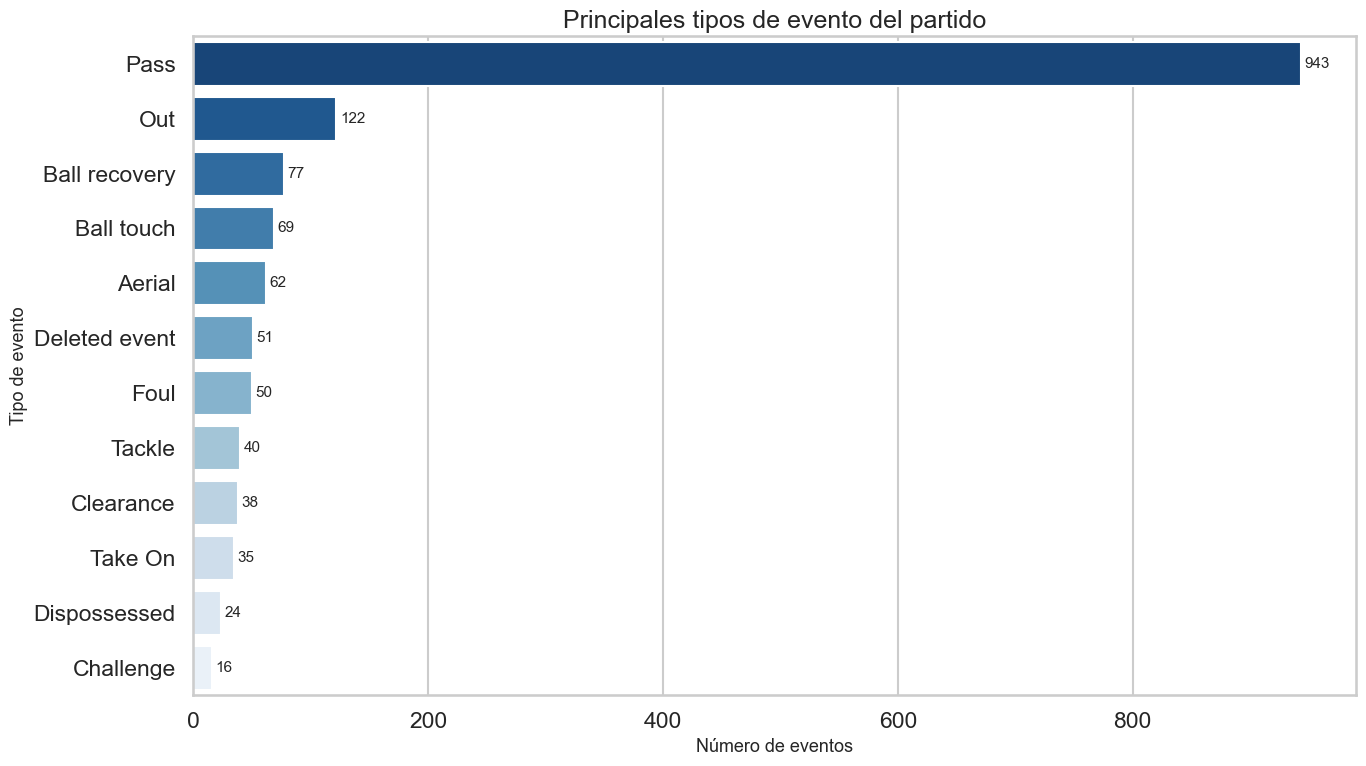

C:\Users\jaime\AppData\Local\Temp\ipykernel_21044\2515191173.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=family_summary, x="event_family", y="n_events", palette="Set2")


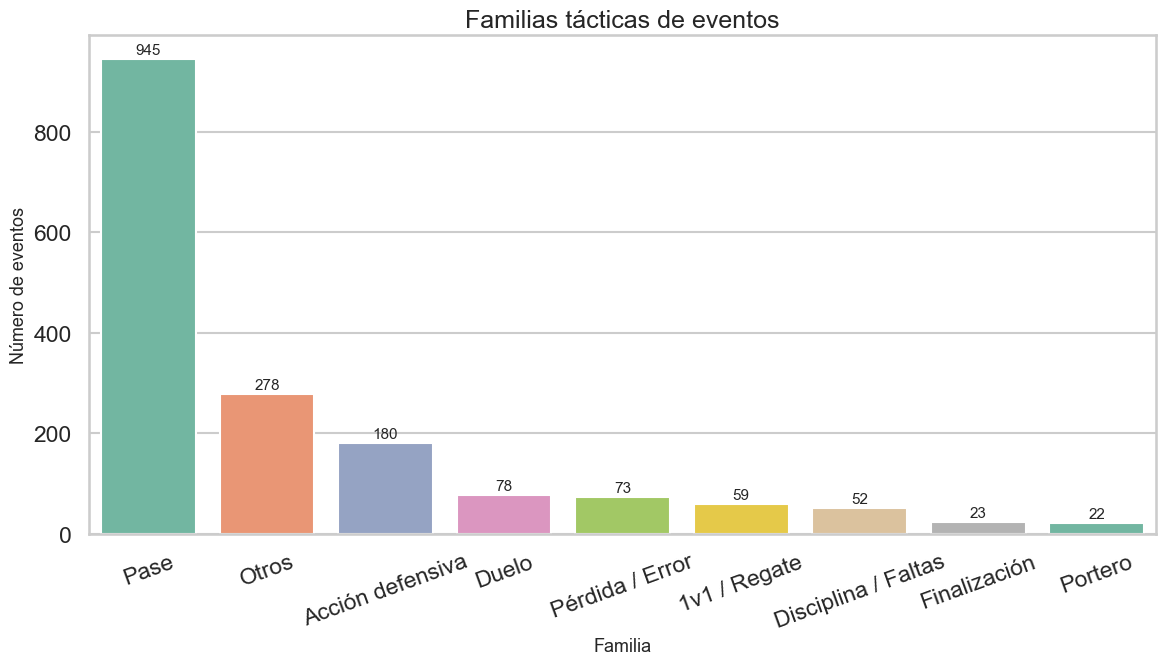

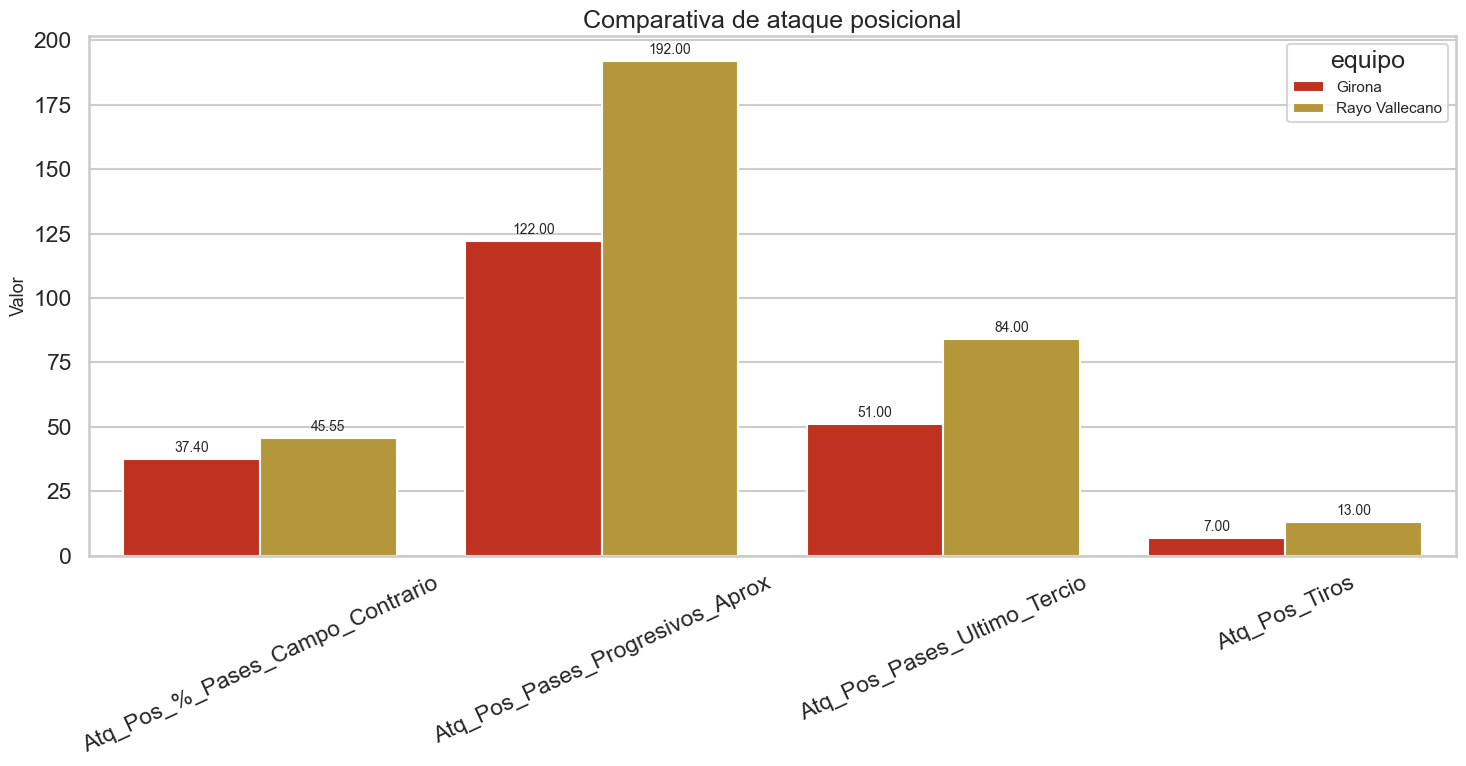

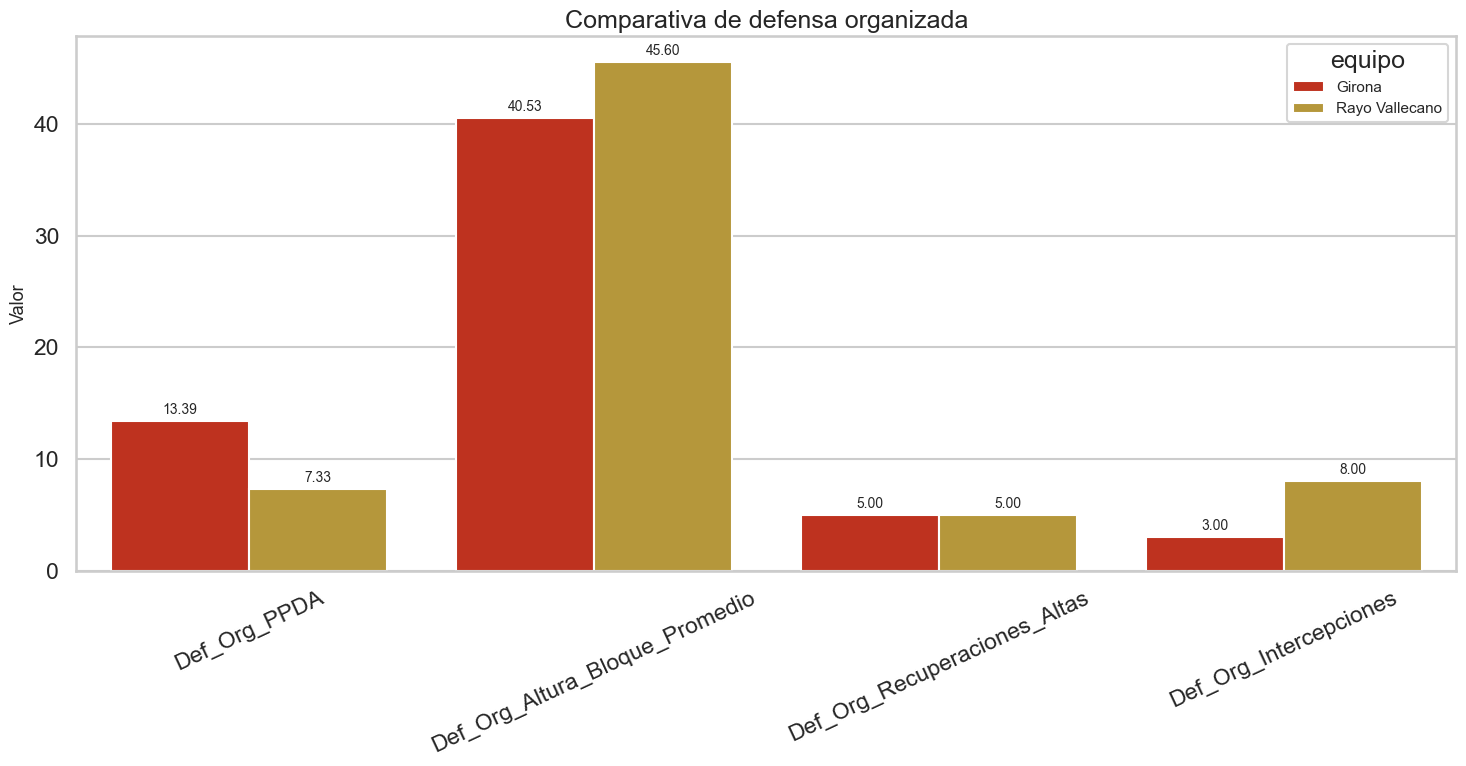

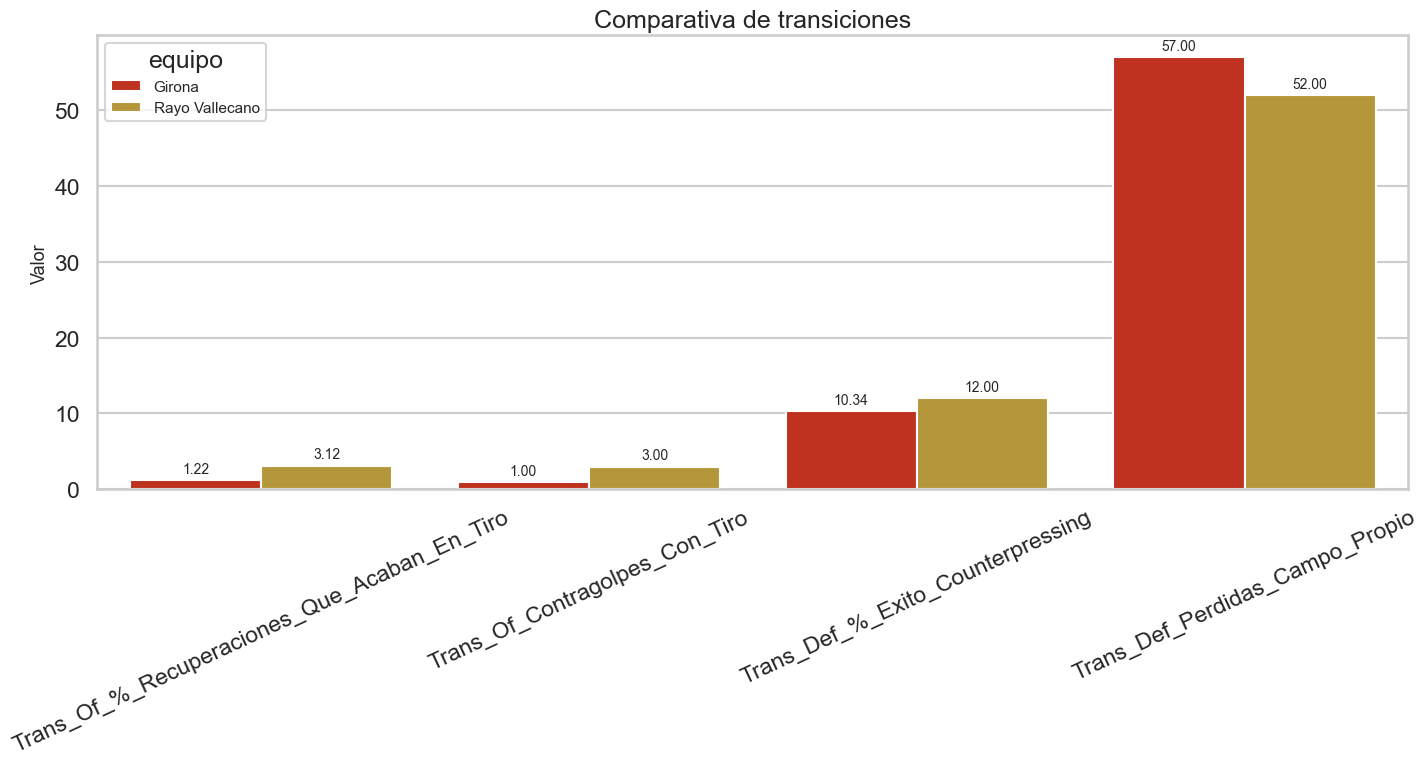

In [14]:
# ============================================================
# CELDA 13. GRÁFICAS DEL PARTIDO
# ============================================================
# Estas gráficas ayudan a explicar el partido de forma visual.

TEAM_COLORS = {
    HOME_NAME: "#D81E05" if "Girona" in HOME_NAME else "#1f77b4",
    AWAY_NAME: "#C9A227" if "Rayo" in AWAY_NAME else "#ff7f0e"
}

# 1. Tipos de evento
plt.figure(figsize=(14, 8))
top_events = event_summary.head(12)
ax = sns.barplot(data=top_events, y="typeName", x="n_events", palette="Blues_r")
plt.title("Principales tipos de evento del partido")
plt.xlabel("Número de eventos")
plt.ylabel("Tipo de evento")
for i, v in enumerate(top_events["n_events"]):
    ax.text(v + 3, i, str(v), va="center", fontsize=11)
plt.tight_layout()
plt.show()

# 2. Familias tácticas
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=family_summary, x="event_family", y="n_events", palette="Set2")
plt.title("Familias tácticas de eventos")
plt.xlabel("Familia")
plt.ylabel("Número de eventos")
plt.xticks(rotation=20)
for i, v in enumerate(family_summary["n_events"]):
    ax.text(i, v + 10, str(v), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

# 3. KPIs comparativos de ataque posicional
attack_metrics = [
    "Atq_Pos_%_Pases_Campo_Contrario",
    "Atq_Pos_Pases_Progresivos_Aprox",
    "Atq_Pos_Pases_Ultimo_Tercio",
    "Atq_Pos_Tiros"
]

attack_df = df_kpis.loc[attack_metrics].reset_index()
attack_df = attack_df.rename(columns={"index": "metric"})
attack_long = attack_df.melt(id_vars="metric", var_name="equipo", value_name="value")

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=attack_long, x="metric", y="value", hue="equipo", palette=TEAM_COLORS)
plt.title("Comparativa de ataque posicional")
plt.xlabel("")
plt.ylabel("Valor")
plt.xticks(rotation=25)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

# 4. KPIs comparativos de defensa organizada
def_metrics = [
    "Def_Org_PPDA",
    "Def_Org_Altura_Bloque_Promedio",
    "Def_Org_Recuperaciones_Altas",
    "Def_Org_Intercepciones"
]

def_df = df_kpis.loc[def_metrics].reset_index()
def_df = def_df.rename(columns={"index": "metric"})
def_long = def_df.melt(id_vars="metric", var_name="equipo", value_name="value")

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=def_long, x="metric", y="value", hue="equipo", palette=TEAM_COLORS)
plt.title("Comparativa de defensa organizada")
plt.xlabel("")
plt.ylabel("Valor")
plt.xticks(rotation=25)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

# 5. KPIs comparativos de transición
trans_metrics = [
    "Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro",
    "Trans_Of_Contragolpes_Con_Tiro",
    "Trans_Def_%_Exito_Counterpressing",
    "Trans_Def_Perdidas_Campo_Propio"
]

trans_df = df_kpis.loc[trans_metrics].reset_index()
trans_df = trans_df.rename(columns={"index": "metric"})
trans_long = trans_df.melt(id_vars="metric", var_name="equipo", value_name="value")

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=trans_long, x="metric", y="value", hue="equipo", palette=TEAM_COLORS)
plt.title("Comparativa de transiciones")
plt.xlabel("")
plt.ylabel("Valor")
plt.xticks(rotation=25)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELDA 14. FOCO ESPECÍFICO: RAYO VALLECANO
# ============================================================
# Esta celda transforma los KPIs en lectura táctica.
# Busca responder:
# - ¿A qué juega el Rayo?
# - ¿Cuáles son sus fortalezas?
# - ¿Cuáles son sus debilidades?

# Detectar el nombre exacto del Rayo en el partido
rayo_name = None
for eq in [equipo_A, equipo_B]:
    if "Rayo" in eq:
        rayo_name = eq

if rayo_name is None:
    print("No se ha detectado automáticamente a Rayo Vallecano. Revisa el nombre del equipo.")
else:
    rival_name = opponent_name(rayo_name)
    print("Equipo analizado:", rayo_name)
    print("Rival:", rival_name)

    rayo = df_kpis[rayo_name]
    rival = df_kpis[rival_name]

    display(pd.DataFrame({
        "Rayo Vallecano": rayo,
        "Rival": rival
    }))

Equipo analizado: Rayo Vallecano
Rival: Girona


,Rayo Vallecano,Rival
Atq_Pos_%_Pases_Campo_Contrario,45.55,37.40
Atq_Pos_Pases_Progresivos_Aprox,192.00,122.00
Atq_Pos_Pases_Ultimo_Tercio,84.00,51.00
Atq_Pos_Centros_Intentados,0.00,0.00
Atq_Pos_%_Acierto_Centros,NaN,NaN
Atq_Pos_Tiros,13.00,7.00
Atq_Pos_Big_Chances,0.00,0.00
Def_Org_Altura_Bloque_Promedio,45.60,40.53
Def_Org_PPDA,7.33,13.39
Def_Org_Pases_Rival_Salida,242.00,308.00


In [16]:
# ============================================================
# CELDA 15. CONCLUSIONES AUTOMÁTICAS
# ============================================================
# Esta celda convierte los números en frases comprensibles.
# Está pensada para que un entrenador pueda leer una síntesis rápida.

def interpret_rayo_style(df_kpis, rayo_name, rival_name):
    rayo = df_kpis[rayo_name]
    rival = df_kpis[rival_name]

    conclusions = []

    # --------------------------------------------------------
    # ATAQUE POSICIONAL
    # --------------------------------------------------------
    if rayo["Atq_Pos_%_Pases_Campo_Contrario"] > rival["Atq_Pos_%_Pases_Campo_Contrario"]:
        conclusions.append(
            f"En ataque posicional, {rayo_name} jugó más tiempo en campo rival que su oponente "
            f"({rayo['Atq_Pos_%_Pases_Campo_Contrario']}% vs {rival['Atq_Pos_%_Pases_Campo_Contrario']}%). "
            f"Esto sugiere capacidad para instalarse arriba y empujar al rival hacia atrás."
        )
    else:
        conclusions.append(
            f"En ataque posicional, {rayo_name} pasó menos tiempo en campo rival que su oponente "
            f"({rayo['Atq_Pos_%_Pases_Campo_Contrario']}% vs {rival['Atq_Pos_%_Pases_Campo_Contrario']}%). "
            f"Esto puede indicar dificultades para asentarse de forma prolongada en terreno contrario."
        )

    if rayo["Atq_Pos_Pases_Ultimo_Tercio"] > rival["Atq_Pos_Pases_Ultimo_Tercio"]:
        conclusions.append(
            f"El equipo alcanzó el último tercio con mayor frecuencia ({rayo['Atq_Pos_Pases_Ultimo_Tercio']} vs {rival['Atq_Pos_Pases_Ultimo_Tercio']}), "
            f"lo que indica buena capacidad para llevar la posesión a zonas ofensivas."
        )
    else:
        conclusions.append(
            f"El acceso al último tercio fue inferior al del rival ({rayo['Atq_Pos_Pases_Ultimo_Tercio']} vs {rival['Atq_Pos_Pases_Ultimo_Tercio']}). "
            f"Eso puede sugerir problemas en la progresión o en el último pase."
        )

    if rayo["Atq_Pos_Tiros"] > rival["Atq_Pos_Tiros"]:
        conclusions.append(
            f"En ataques organizados, {rayo_name} finalizó más ({rayo['Atq_Pos_Tiros']} tiros vs {rival['Atq_Pos_Tiros']}). "
            f"Esto refuerza la idea de un equipo capaz de convertir posesión en remate."
        )
    else:
        conclusions.append(
            f"En ataque posicional, el volumen de tiro fue inferior al rival ({rayo['Atq_Pos_Tiros']} vs {rival['Atq_Pos_Tiros']}). "
            f"Eso puede indicar posesión con menos profundidad o menos claridad en zonas de remate."
        )

    # --------------------------------------------------------
    # DEFENSA ORGANIZADA
    # --------------------------------------------------------
    if rayo["Def_Org_PPDA"] < rival["Def_Org_PPDA"]:
        conclusions.append(
            f"Defensivamente, {rayo_name} mostró una presión más agresiva: su PPDA fue menor "
            f"({rayo['Def_Org_PPDA']} vs {rival['Def_Org_PPDA']}). "
            f"Eso significa que permitió menos pases en salida antes de intervenir."
        )
    else:
        conclusions.append(
            f"El PPDA de {rayo_name} fue más alto ({rayo['Def_Org_PPDA']} vs {rival['Def_Org_PPDA']}), "
            f"por lo que su presión en salida rival fue menos intensa o menos efectiva."
        )

    if rayo["Def_Org_Intercepciones"] > rival["Def_Org_Intercepciones"]:
        conclusions.append(
            f"El equipo interceptó más pases que su rival ({rayo['Def_Org_Intercepciones']} vs {rival['Def_Org_Intercepciones']}). "
            f"Esto habla bien de su capacidad para leer líneas de pase y anticipar."
        )

    if rayo["Def_Org_Recuperaciones_Altas"] >= rival["Def_Org_Recuperaciones_Altas"]:
        conclusions.append(
            f"Las recuperaciones altas fueron al menos iguales o superiores a las del rival "
            f"({rayo['Def_Org_Recuperaciones_Altas']} vs {rival['Def_Org_Recuperaciones_Altas']}). "
            f"Eso sugiere capacidad para robar arriba y sostener presión."
        )

    # --------------------------------------------------------
    # TRANSICIÓN OFENSIVA
    # --------------------------------------------------------
    if rayo["Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro"] > rival["Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro"]:
        conclusions.append(
            f"Tras recuperar, {rayo_name} fue más dañino: un mayor porcentaje de sus recuperaciones acabó en tiro "
            f"({rayo['Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro']}% vs {rival['Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro']}%). "
            f"Esto encaja con un equipo vertical y peligroso al correr."
        )
    else:
        conclusions.append(
            f"En transición ofensiva, {rayo_name} generó menos tiros por recuperación que el rival "
            f"({rayo['Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro']}% vs {rival['Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro']}%). "
            f"Esto puede reflejar que roba pero no siempre transforma esas recuperaciones en amenaza real."
        )

    # --------------------------------------------------------
    # TRANSICIÓN DEFENSIVA
    # --------------------------------------------------------
    if rayo["Trans_Def_%_Exito_Counterpressing"] > rival["Trans_Def_%_Exito_Counterpressing"]:
        conclusions.append(
            f"Tras pérdida, {rayo_name} reaccionó mejor: su porcentaje de counterpressing exitoso fue superior "
            f"({rayo['Trans_Def_%_Exito_Counterpressing']}% vs {rival['Trans_Def_%_Exito_Counterpressing']}%). "
            f"Esto sugiere una buena respuesta inmediata para frenar transiciones rivales."
        )
    else:
        conclusions.append(
            f"La reacción tras pérdida fue inferior a la del rival "
            f"({rayo['Trans_Def_%_Exito_Counterpressing']}% vs {rival['Trans_Def_%_Exito_Counterpressing']}%). "
            f"Eso puede dejar al equipo más expuesto cuando pierde la pelota."
        )

    if rayo["Trans_Def_Perdidas_Campo_Propio"] > rival["Trans_Def_Perdidas_Campo_Propio"]:
        conclusions.append(
            f"Una debilidad clara fue el número de pérdidas en campo propio "
            f"({rayo['Trans_Def_Perdidas_Campo_Propio']} vs {rival['Trans_Def_Perdidas_Campo_Propio']}). "
            f"Perder cerca de la propia portería aumenta mucho el riesgo."
        )
    else:
        conclusions.append(
            f"El equipo protegió relativamente mejor sus pérdidas en campo propio "
            f"({rayo['Trans_Def_Perdidas_Campo_Propio']} vs {rival['Trans_Def_Perdidas_Campo_Propio']})."
        )

    if rayo["Trans_Def_Errores_Que_Generan_Gol"] > 0:
        conclusions.append(
            f"Se detectaron errores propios que terminaron generando gol ({rayo['Trans_Def_Errores_Que_Generan_Gol']}). "
            f"Esto es una señal de vulnerabilidad crítica."
        )

    return conclusions


if rayo_name is not None:
    conclusions = interpret_rayo_style(df_kpis, rayo_name, rival_name)

    print("=== CONCLUSIONES AUTOMÁTICAS SOBRE EL TIPO DE JUEGO DEL RAYO VALLECANO ===\n")
    for i, c in enumerate(conclusions, 1):
        print(f"{i}. {c}")

=== CONCLUSIONES AUTOMÁTICAS SOBRE EL TIPO DE JUEGO DEL RAYO VALLECANO ===

1. En ataque posicional, Rayo Vallecano jugó más tiempo en campo rival que su oponente (45.55% vs 37.4%). Esto sugiere capacidad para instalarse arriba y empujar al rival hacia atrás.
2. El equipo alcanzó el último tercio con mayor frecuencia (84.0 vs 51.0), lo que indica buena capacidad para llevar la posesión a zonas ofensivas.
3. En ataques organizados, Rayo Vallecano finalizó más (13.0 tiros vs 7.0). Esto refuerza la idea de un equipo capaz de convertir posesión en remate.
4. Defensivamente, Rayo Vallecano mostró una presión más agresiva: su PPDA fue menor (7.33 vs 13.39). Eso significa que permitió menos pases en salida antes de intervenir.
5. El equipo interceptó más pases que su rival (8.0 vs 3.0). Esto habla bien de su capacidad para leer líneas de pase y anticipar.
6. Las recuperaciones altas fueron al menos iguales o superiores a las del rival (5.0 vs 5.0). Eso sugiere capacidad para robar arriba y so

In [17]:
# ============================================================
# CELDA 16. RESUMEN EJECUTIVO: FORTALEZAS Y DEBILIDADES
# ============================================================
# Esta última celda organiza el análisis en formato más ejecutivo.

def classify_strengths_weaknesses(df_kpis, team_name, rival_name):
    team = df_kpis[team_name]
    rival = df_kpis[rival_name]

    fortalezas = []
    debilidades = []

    # Fortalezas
    if team["Def_Org_PPDA"] < rival["Def_Org_PPDA"]:
        fortalezas.append("Presión alta más agresiva que el rival (PPDA menor).")

    if team["Def_Org_Intercepciones"] > rival["Def_Org_Intercepciones"]:
        fortalezas.append("Buena capacidad de anticipación e intercepción.")

    if team["Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro"] > rival["Trans_Of_%_Recuperaciones_Que_Acaban_En_Tiro"]:
        fortalezas.append("Transiciones ofensivas más dañinas: convierte recuperaciones en tiros con frecuencia.")

    if team["Atq_Pos_Pases_Ultimo_Tercio"] > rival["Atq_Pos_Pases_Ultimo_Tercio"]:
        fortalezas.append("Capacidad para llegar al último tercio con frecuencia.")

    if team["Atq_Pos_Tiros"] > rival["Atq_Pos_Tiros"]:
        fortalezas.append("Consigue finalizar mejor sus ataques posicionales.")

    if team["Trans_Def_%_Exito_Counterpressing"] > rival["Trans_Def_%_Exito_Counterpressing"]:
        fortalezas.append("Buena reacción inmediata tras pérdida.")

    # Debilidades
    if team["Trans_Def_Perdidas_Campo_Propio"] > rival["Trans_Def_Perdidas_Campo_Propio"]:
        debilidades.append("Exceso de pérdidas en campo propio, que aumentan el riesgo defensivo.")

    if team["Atq_Pos_%_Acierto_Centros"] < rival["Atq_Pos_%_Acierto_Centros"]:
        debilidades.append("Menor eficacia en centros que el rival.")

    if team["Atq_Pos_%_Pases_Campo_Contrario"] < rival["Atq_Pos_%_Pases_Campo_Contrario"]:
        debilidades.append("Le cuesta más asentarse en campo contrario durante ataques organizados.")

    if team["Trans_Def_Errores_Que_Generan_Tiro"] > 0:
        debilidades.append("Comete errores tras pérdida que pueden conceder ocasiones al rival.")

    if team["Trans_Def_Errores_Que_Generan_Gol"] > 0:
        debilidades.append("Ha cometido errores de máxima penalización: alguno terminó en gol.")

    return fortalezas, debilidades


if rayo_name is not None:
    fortalezas, debilidades = classify_strengths_weaknesses(df_kpis, rayo_name, rival_name)

    print("=== PERFIL DEL RAYO VALLECANO ===\n")

    print("FORTALEZAS")
    if len(fortalezas) == 0:
        print("- No se detectan fortalezas muy dominantes frente al rival con este partido como única muestra.")
    else:
        for f in fortalezas:
            print("-", f)

    print("\nDEBILIDADES")
    if len(debilidades) == 0:
        print("- No se detectan debilidades muy marcadas frente al rival con este partido como única muestra.")
    else:
        for d in debilidades:
            print("-", d)

=== PERFIL DEL RAYO VALLECANO ===

FORTALEZAS
- Presión alta más agresiva que el rival (PPDA menor).
- Buena capacidad de anticipación e intercepción.
- Transiciones ofensivas más dañinas: convierte recuperaciones en tiros con frecuencia.
- Capacidad para llegar al último tercio con frecuencia.
- Consigue finalizar mejor sus ataques posicionales.
- Buena reacción inmediata tras pérdida.

DEBILIDADES
- No se detectan debilidades muy marcadas frente al rival con este partido como única muestra.
